# MeatLens Classical Segmentation Experiment Only

This notebook is a **classical segmentation experiment only** for MeatLens.

Scope:
- pork-region background removal / segmentation testing
- visual comparison of multiple classical methods
- segmentation quality statistics and failure analysis

Guardrails:
- this is **not** the main model training notebook
- this does **not** claim final production segmentation
- this does **not** use the public dataset
- this does **not** train any segmented classifier
- all outputs are written only to `training_outputs/segmentation_experiment/`


In [1]:
# ============================================================
# Imports and package availability checks
# ============================================================
import importlib
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps
from IPython.display import display
from scipy import ndimage as ndi

def optional_import(module_name):
    try:
        return importlib.import_module(module_name)
    except Exception:
        return None

cv2 = optional_import("cv2")
skimage = optional_import("skimage")
skcolor = optional_import("skimage.color")
skfeature = optional_import("skimage.feature")
skmorphology = optional_import("skimage.morphology")
skmeasure = optional_import("skimage.measure")

CV2_AVAILABLE = cv2 is not None
SKIMAGE_AVAILABLE = all(mod is not None for mod in [skimage, skcolor, skfeature, skmorphology, skmeasure])
PIL_AVAILABLE = True

if SKIMAGE_AVAILABLE:
    binary_opening = skmorphology.binary_opening
    binary_closing = skmorphology.binary_closing
    remove_small_holes = skmorphology.remove_small_holes
    remove_small_objects = skmorphology.remove_small_objects
    disk = skmorphology.disk
    sk_label = skmeasure.label
else:
    binary_opening = None
    binary_closing = None
    remove_small_holes = None
    remove_small_objects = None
    disk = None
    sk_label = None

plt.style.use("default")
warnings.filterwarnings("ignore")

import sys
print("Python executable:", sys.executable)
print("NumPy version:", np.__version__)
if CV2_AVAILABLE:
    print("cv2 available:", True, "| version:", getattr(cv2, "__version__", "unknown"))
else:
    print("cv2 available:", False)
    print("[WARN] OpenCV is unavailable. GrabCut methods will be skipped safely.")
if SKIMAGE_AVAILABLE:
    print("scikit-image available:", True, "| version:", getattr(skimage, "__version__", "unknown"))
else:
    print("scikit-image available:", False)
    print("[WARN] scikit-image is unavailable. Some mask cleaning utilities will be limited.")
print("PIL available:", PIL_AVAILABLE)


Python executable: e:\Thesis Code\.venv-gpu\Scripts\python.exe
NumPy version: 1.26.4
cv2 available: True | version: 4.10.0
scikit-image available: True | version: 0.25.2
PIL available: True


In [2]:
# ============================================================
# Configuration
# ============================================================
PROJECT_ROOT = Path.cwd()
CROSS_ROTATION_ROOT = PROJECT_ROOT / "generated_splits" / "cross_rotation"

SEGMENTATION_OUTPUT_ROOT = PROJECT_ROOT / "training_outputs" / "segmentation_experiment"
FIGURES_ROOT = SEGMENTATION_OUTPUT_ROOT / "figures"
MASKS_ROOT = SEGMENTATION_OUTPUT_ROOT / "masks"
PREVIEWS_ROOT = SEGMENTATION_OUTPUT_ROOT / "previews"
CSV_ROOT = SEGMENTATION_OUTPUT_ROOT / "csv"

for path_obj in [SEGMENTATION_OUTPUT_ROOT, FIGURES_ROOT, MASKS_ROOT, PREVIEWS_ROOT, CSV_ROOT]:
    path_obj.mkdir(parents=True, exist_ok=True)

RUN_SEGMENTATION_EXPERIMENT = False
IMAGE_CROP_MODE = "center_square_resize_224"
TARGET_SIZE = (224, 224)
LABEL_ORDER = ["fresh", "not fresh", "spoiled"]
FOLDS = ["fold1", "fold2", "fold3", "fold4"]
SEGMENTATION_METHODS = [
    "hsv_lab_threshold",
    "hsv_lab_rgb_threshold",
    "grabcut_center_rectangle",
    "threshold_plus_grabcut_refinement",
]

SAMPLE_METADATA = {
    "pork_shoulder_sample_1": {"capture_source": "researcher_home", "pork_cut": "shoulder"},
    "pork_shoulder_sample_2": {"capture_source": "partner_home", "pork_cut": "shoulder"},
    "pork_belly_sample_3": {"capture_source": "researcher_home", "pork_cut": "belly"},
    "pork_belly_sample_4": {"capture_source": "partner_home", "pork_cut": "belly"},
}
SAMPLE_NUMBER_TO_ID = {
    "1": "pork_shoulder_sample_1",
    "2": "pork_shoulder_sample_2",
    "3": "pork_belly_sample_3",
    "4": "pork_belly_sample_4",
}

IMAGE_PATH_CANDIDATES = [
    "image_path",
    "file_path",
    "path",
    "filename",
    "image_file",
    "roi_file",
    "file_destination",
    "image_file_name",
]

SPLIT_FILES = {
    f"{fold}_{part}": CROSS_ROTATION_ROOT / f"{fold}_{part}.csv"
    for fold in FOLDS
    for part in ["train", "val", "test"]
}

print("RUN_SEGMENTATION_EXPERIMENT =", RUN_SEGMENTATION_EXPERIMENT)
print("IMAGE_CROP_MODE =", IMAGE_CROP_MODE)
print("SEGMENTATION_OUTPUT_ROOT =", SEGMENTATION_OUTPUT_ROOT)


RUN_SEGMENTATION_EXPERIMENT = False
IMAGE_CROP_MODE = center_square_resize_224
SEGMENTATION_OUTPUT_ROOT = e:\Thesis Code\training_outputs\segmentation_experiment


In [3]:
# ============================================================
# Split loading and path resolution
# ============================================================
def detect_image_path_column(df: pd.DataFrame):
    for col_name in IMAGE_PATH_CANDIDATES:
        if col_name in df.columns:
            return col_name
    return None


def resolve_image_path(row, path_col, csv_path=None):
    if path_col is None:
        return None
    raw = row.get(path_col, None)
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None
    raw_str = str(raw).strip()
    if raw_str == "":
        return None

    candidates = [Path(raw_str)]
    if csv_path is not None:
        candidates.append(Path(csv_path).resolve().parent / raw_str)
    candidates.append(PROJECT_ROOT / raw_str)

    for candidate in candidates:
        try:
            resolved = candidate.expanduser().resolve(strict=False)
        except Exception:
            resolved = candidate
        if Path(resolved).exists():
            return str(Path(resolved))
    return None


def normalize_sample_id(row):
    sample_id_raw = row.get("sample_id", None)
    if sample_id_raw is not None and not (isinstance(sample_id_raw, float) and pd.isna(sample_id_raw)):
        sample_id_str = str(sample_id_raw).strip().lower()
        if sample_id_str not in ["", "nan", "none"]:
            return sample_id_str

    sample_number_raw = row.get("sample_number", None)
    if sample_number_raw is None or (isinstance(sample_number_raw, float) and pd.isna(sample_number_raw)):
        return None
    sample_number_str = str(sample_number_raw).strip()
    if sample_number_str.endswith(".0"):
        sample_number_str = sample_number_str[:-2]
    return SAMPLE_NUMBER_TO_ID.get(sample_number_str, None)


def load_split_dataframe(csv_path: Path, split_key: str):
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing split file: {csv_path}")

    df = pd.read_csv(csv_path)
    df["split_key"] = split_key
    df["split_name"] = split_key.split("_")[0]
    df["dataset_partition"] = split_key.split("_")[1]

    path_col = detect_image_path_column(df)
    if path_col is None:
        raise ValueError(f"No image path column found in {csv_path.name}")

    df["image_path_source_column"] = path_col
    df["image_path_resolved"] = df.apply(
        lambda row: resolve_image_path(row, path_col=path_col, csv_path=csv_path),
        axis=1,
    )
    df["sample_id"] = df.apply(normalize_sample_id, axis=1)
    df["capture_source"] = df["sample_id"].map(lambda x: SAMPLE_METADATA.get(x, {}).get("capture_source"))
    df["pork_cut"] = df["sample_id"].map(lambda x: SAMPLE_METADATA.get(x, {}).get("pork_cut"))
    return df


SPLIT_DATA = {split_key: load_split_dataframe(csv_path, split_key) for split_key, csv_path in SPLIT_FILES.items()}
CLEAN_SPLIT_DATA = {
    split_key: df.loc[~df["image_path_resolved"].isna()].reset_index(drop=True).copy()
    for split_key, df in SPLIT_DATA.items()
}

split_summary = pd.DataFrame(
    [
        {
            "split_key": split_key,
            "rows": len(df),
            "resolved_rows": int(df["image_path_resolved"].notna().sum()),
            "missing_rows": int(df["image_path_resolved"].isna().sum()),
        }
        for split_key, df in SPLIT_DATA.items()
    ]
)
display(split_summary)


,split_key,rows,resolved_rows,missing_rows
0,fold1_train,1161,1160,1
1,fold1_val,205,205,0
2,fold1_test,485,485,0
3,fold2_train,1187,1187,0
4,fold2_val,210,210,0
5,fold2_test,454,453,1
6,fold3_train,1199,1198,1
7,fold3_val,212,212,0
8,fold3_test,440,440,0
9,fold4_train,1172,1171,1


In [4]:
# ============================================================
# Representative image selection preview
# ============================================================
def select_representative_images():
    pool = pd.concat(CLEAN_SPLIT_DATA.values(), ignore_index=True)
    selected_frames = []

    for sample_id, sample_df in pool.groupby("sample_id", dropna=False):
        sample_df = sample_df.sort_values(["label", "split_name", "dataset_partition", "image_file_name"]).reset_index(drop=True)
        picked_idx = []
        for label_name in LABEL_ORDER:
            label_rows = sample_df.index[sample_df["label"] == label_name].tolist()
            if len(label_rows) > 0:
                picked_idx.append(label_rows[0])
        for idx in sample_df.index.tolist():
            if idx not in picked_idx:
                picked_idx.append(idx)
            if len(picked_idx) >= 3:
                break
        selected_frames.append(sample_df.loc[sorted(set(picked_idx[:3]))].copy())

    selected_df = pd.concat(selected_frames, ignore_index=True)
    selected_df = selected_df[
        [
            "image_path_resolved",
            "sample_id",
            "pork_cut",
            "capture_source",
            "label",
            "split_name",
            "dataset_partition",
        ]
    ].copy()
    return selected_df


SELECTED_IMAGES_DF = select_representative_images()
selected_csv_path = CSV_ROOT / "selected_segmentation_preview_images.csv"
SELECTED_IMAGES_DF.to_csv(selected_csv_path, index=False)
display(SELECTED_IMAGES_DF.head(12))
print(f"Saved: {selected_csv_path}")


,image_path_resolved,sample_id,pork_cut,capture_source,label,split_name,dataset_partition
0,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...,pork_belly_sample_3,belly,researcher_home,fresh,fold1,train
1,E:\Thesis Code\Pork Belly - Sample 3\Not Fresh...,pork_belly_sample_3,belly,researcher_home,not fresh,fold1,train
2,E:\Thesis Code\Pork Belly - Sample 3\Spoiled -...,pork_belly_sample_3,belly,researcher_home,spoiled,fold1,train
3,E:\Thesis Code\Pork Belly - Sample 4\Fresh - 0...,pork_belly_sample_4,belly,partner_home,fresh,fold1,train
4,E:\Thesis Code\Pork Belly - Sample 4\Not fresh...,pork_belly_sample_4,belly,partner_home,not fresh,fold1,train
5,E:\Thesis Code\Pork Belly - Sample 4\Spoiled -...,pork_belly_sample_4,belly,partner_home,spoiled,fold1,train
6,E:\Thesis Code\Pork Shoulder - sample 1\Fresh ...,pork_shoulder_sample_1,shoulder,researcher_home,fresh,fold1,test
7,E:\Thesis Code\Pork Shoulder - sample 1\Not Fr...,pork_shoulder_sample_1,shoulder,researcher_home,not fresh,fold1,test
8,E:\Thesis Code\Pork Shoulder - sample 1\Spoile...,pork_shoulder_sample_1,shoulder,researcher_home,spoiled,fold1,test
9,E:\Thesis Code\Pork Shoulder - sample 2\Fresh ...,pork_shoulder_sample_2,shoulder,partner_home,fresh,fold1,train


Saved: e:\Thesis Code\training_outputs\segmentation_experiment\csv\selected_segmentation_preview_images.csv


In [5]:
# ============================================================
# Center-square preprocessing and classical segmentation methods
# ============================================================
def preprocess_center_square_resize_224(img: Image.Image):
    img = img.convert("RGB")
    width, height = img.size
    side = min(width, height)
    left = (width - side) // 2
    top = (height - side) // 2
    square = img.crop((left, top, left + side, top + side))
    return square.resize(TARGET_SIZE, Image.BILINEAR)


def load_center_square_resize_224(path):
    img = Image.open(path).convert("RGB")
    original_np = np.array(img)
    processed = preprocess_center_square_resize_224(img)
    processed_np = np.array(processed)
    return original_np, processed_np


def get_hsv_channels(image_uint8):
    hsv = np.array(Image.fromarray(image_uint8, mode="RGB").convert("HSV"), dtype=np.float32)
    return hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]


def get_lab_channels(image_uint8):
    if SKIMAGE_AVAILABLE:
        lab = skcolor.rgb2lab(image_uint8 / 255.0).astype(np.float32)
        l = lab[:, :, 0]
        a = lab[:, :, 1]
        b = lab[:, :, 2]
        return l, a, b
    if CV2_AVAILABLE:
        lab = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2LAB).astype(np.float32)
        l = lab[:, :, 0] * (100.0 / 255.0)
        a = lab[:, :, 1] - 128.0
        b = lab[:, :, 2] - 128.0
        return l, a, b
    return None, None, None


def component_stats(mask_bool):
    labeled, num = ndi.label(mask_bool.astype(np.uint8))
    stats = []
    height, width = mask_bool.shape
    center_y, center_x = (height - 1) / 2.0, (width - 1) / 2.0
    yy, xx = np.mgrid[0:height, 0:width]
    central_region = np.zeros_like(mask_bool, dtype=bool)
    y0, y1 = int(height * 0.25), int(height * 0.75)
    x0, x1 = int(width * 0.25), int(width * 0.75)
    central_region[y0:y1, x0:x1] = True

    for comp_id in range(1, num + 1):
        comp_mask = labeled == comp_id
        area = int(comp_mask.sum())
        if area == 0:
            continue
        cy = float(yy[comp_mask].mean())
        cx = float(xx[comp_mask].mean())
        dist = math.sqrt((cy - center_y) ** 2 + (cx - center_x) ** 2)
        dist_norm = dist / max(math.sqrt(center_y ** 2 + center_x ** 2), 1e-6)
        center_overlap = float((comp_mask & central_region).sum()) / max(float(central_region.sum()), 1.0)
        score = (2.0 * (area / float(mask_bool.size))) + (2.5 * center_overlap) - (1.25 * dist_norm)
        stats.append(
            {
                "component_id": comp_id,
                "mask": comp_mask,
                "area": area,
                "center_overlap": center_overlap,
                "distance_norm": dist_norm,
                "score": score,
            }
        )
    return labeled, stats, central_region


def clean_mask(mask_input):
    mask = np.asarray(mask_input).astype(bool)

    if SKIMAGE_AVAILABLE:
        mask = binary_opening(mask, disk(3))
        mask = binary_closing(mask, disk(5))
        mask = remove_small_holes(mask, area_threshold=256)
        mask = remove_small_objects(mask, min_size=250)
    elif CV2_AVAILABLE:
        kernel_open = np.ones((3, 3), np.uint8)
        kernel_close = np.ones((5, 5), np.uint8)
        mask_uint8 = (mask.astype(np.uint8) * 255)
        mask_uint8 = cv2.morphologyEx(mask_uint8, cv2.MORPH_OPEN, kernel_open)
        mask_uint8 = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, kernel_close)
        mask = mask_uint8 > 0

    mask = ndi.binary_fill_holes(mask)
    labeled, stats, central_region = component_stats(mask)

    filtered_stats = [item for item in stats if item["area"] >= 200]
    if len(filtered_stats) == 0:
        return np.zeros_like(mask, dtype=bool), {
            "touches_border": False,
            "number_of_components": 0,
            "center_overlap_ratio": 0.0,
            "mask_area_ratio": 0.0,
        }

    best = sorted(filtered_stats, key=lambda item: item["score"], reverse=True)[0]
    final_mask = best["mask"]
    touches_border = bool(
        final_mask[0, :].any() or final_mask[-1, :].any() or final_mask[:, 0].any() or final_mask[:, -1].any()
    )
    quality = {
        "touches_border": touches_border,
        "number_of_components": len(filtered_stats),
        "center_overlap_ratio": float(best["center_overlap"]),
        "mask_area_ratio": float(final_mask.mean()),
    }
    return final_mask.astype(bool), quality


def failure_flag(mask_bool, quality):
    if mask_bool.sum() == 0:
        return True
    if quality["mask_area_ratio"] < 0.20:
        return True
    if quality["mask_area_ratio"] > 0.95:
        return True
    if quality["center_overlap_ratio"] < 0.08:
        return True
    return False


def apply_background_fill(image_uint8, mask_bool, mode="gray"):
    image_float = image_uint8.astype(np.float32)
    if mode == "black":
        bg = np.zeros_like(image_float)
    elif mode == "mean":
        mean_color = image_float.mean(axis=(0, 1), keepdims=True)
        bg = np.ones_like(image_float) * mean_color
    else:
        bg = np.ones_like(image_float) * 127.0
    out = bg.copy()
    out[mask_bool] = image_float[mask_bool]
    return np.clip(out, 0, 255).astype(np.uint8)


def method_hsv_lab_threshold(image_uint8):
    h, s, v = get_hsv_channels(image_uint8)
    l, a, b = get_lab_channels(image_uint8)
    if l is None:
        raise RuntimeError("LAB conversion unavailable.")
    mask = (
        (s >= 20) &
        (v >= 35) &
        ~( (v >= 235) & (s <= 30) ) &
        (a >= 6.0)
    )
    return mask


def method_hsv_lab_rgb_threshold(image_uint8):
    base_mask = method_hsv_lab_threshold(image_uint8)
    r = image_uint8[:, :, 0].astype(np.float32)
    g = image_uint8[:, :, 1].astype(np.float32)
    b = image_uint8[:, :, 2].astype(np.float32)
    rgb_mask = (
        (r >= 65) &
        (r >= (g - 10)) &
        (r >= (b - 10)) &
        ~((r >= 235) & (g >= 235) & (b >= 235))
    )
    return base_mask & rgb_mask


def method_grabcut_center_rectangle(image_uint8):
    if not CV2_AVAILABLE:
        return None
    h, w = image_uint8.shape[:2]
    rect = (int(0.10 * w), int(0.10 * h), int(0.80 * w), int(0.80 * h))
    gc_mask = np.zeros((h, w), np.uint8)
    bgd = np.zeros((1, 65), np.float64)
    fgd = np.zeros((1, 65), np.float64)
    try:
        cv2.grabCut(cv2.cvtColor(image_uint8, cv2.COLOR_RGB2BGR), gc_mask, rect, bgd, fgd, 5, cv2.GC_INIT_WITH_RECT)
        return np.isin(gc_mask, [cv2.GC_FGD, cv2.GC_PR_FGD])
    except Exception:
        return None


def method_threshold_plus_grabcut_refinement(image_uint8):
    threshold_mask = method_hsv_lab_rgb_threshold(image_uint8)
    if not CV2_AVAILABLE:
        return threshold_mask

    h, w = image_uint8.shape[:2]
    gc_mask = np.full((h, w), cv2.GC_PR_BGD, dtype=np.uint8)
    gc_mask[threshold_mask] = cv2.GC_PR_FGD
    gc_mask[~threshold_mask] = cv2.GC_BGD
    cy0, cy1 = int(h * 0.25), int(h * 0.75)
    cx0, cx1 = int(w * 0.25), int(w * 0.75)
    gc_mask[cy0:cy1, cx0:cx1] = np.where(
        threshold_mask[cy0:cy1, cx0:cx1],
        cv2.GC_FGD,
        gc_mask[cy0:cy1, cx0:cx1],
    )
    bgd = np.zeros((1, 65), np.float64)
    fgd = np.zeros((1, 65), np.float64)
    try:
        cv2.grabCut(
            cv2.cvtColor(image_uint8, cv2.COLOR_RGB2BGR),
            gc_mask,
            None,
            bgd,
            fgd,
            5,
            cv2.GC_INIT_WITH_MASK,
        )
        refined = np.isin(gc_mask, [cv2.GC_FGD, cv2.GC_PR_FGD])
        if refined.sum() == 0:
            return threshold_mask
        return refined
    except Exception:
        return threshold_mask


def run_segmentation_method(method_name, image_uint8):
    if method_name == "hsv_lab_threshold":
        raw_mask = method_hsv_lab_threshold(image_uint8)
    elif method_name == "hsv_lab_rgb_threshold":
        raw_mask = method_hsv_lab_rgb_threshold(image_uint8)
    elif method_name == "grabcut_center_rectangle":
        raw_mask = method_grabcut_center_rectangle(image_uint8)
    elif method_name == "threshold_plus_grabcut_refinement":
        raw_mask = method_threshold_plus_grabcut_refinement(image_uint8)
    else:
        raise ValueError(f"Unknown method: {method_name}")

    if raw_mask is None:
        final_mask = np.zeros(image_uint8.shape[:2], dtype=bool)
        quality = {
            "touches_border": False,
            "number_of_components": 0,
            "center_overlap_ratio": 0.0,
            "mask_area_ratio": 0.0,
        }
        failed = True
    else:
        final_mask, quality = clean_mask(raw_mask)
        failed = failure_flag(final_mask, quality)

    preview_black = apply_background_fill(image_uint8, final_mask, mode="black") if final_mask.any() else image_uint8.copy()
    preview_gray = apply_background_fill(image_uint8, final_mask, mode="gray") if final_mask.any() else image_uint8.copy()
    preview_mean = apply_background_fill(image_uint8, final_mask, mode="mean") if final_mask.any() else image_uint8.copy()
    if failed:
        preview_black = image_uint8.copy()
        preview_gray = image_uint8.copy()
        preview_mean = image_uint8.copy()

    return {
        "mask": final_mask.astype(np.uint8) * 255,
        "mask_bool": final_mask,
        "quality": quality,
        "segmentation_failed": failed,
        "preview_black": preview_black,
        "preview_gray": preview_gray,
        "preview_mean": preview_mean,
    }


,image_path_resolved,sample_id,pork_cut,capture_source,label,split_name,dataset_partition
0,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...,pork_belly_sample_3,belly,researcher_home,fresh,fold1,train
1,E:\Thesis Code\Pork Belly - Sample 3\Not Fresh...,pork_belly_sample_3,belly,researcher_home,not fresh,fold1,train
2,E:\Thesis Code\Pork Belly - Sample 3\Spoiled -...,pork_belly_sample_3,belly,researcher_home,spoiled,fold1,train


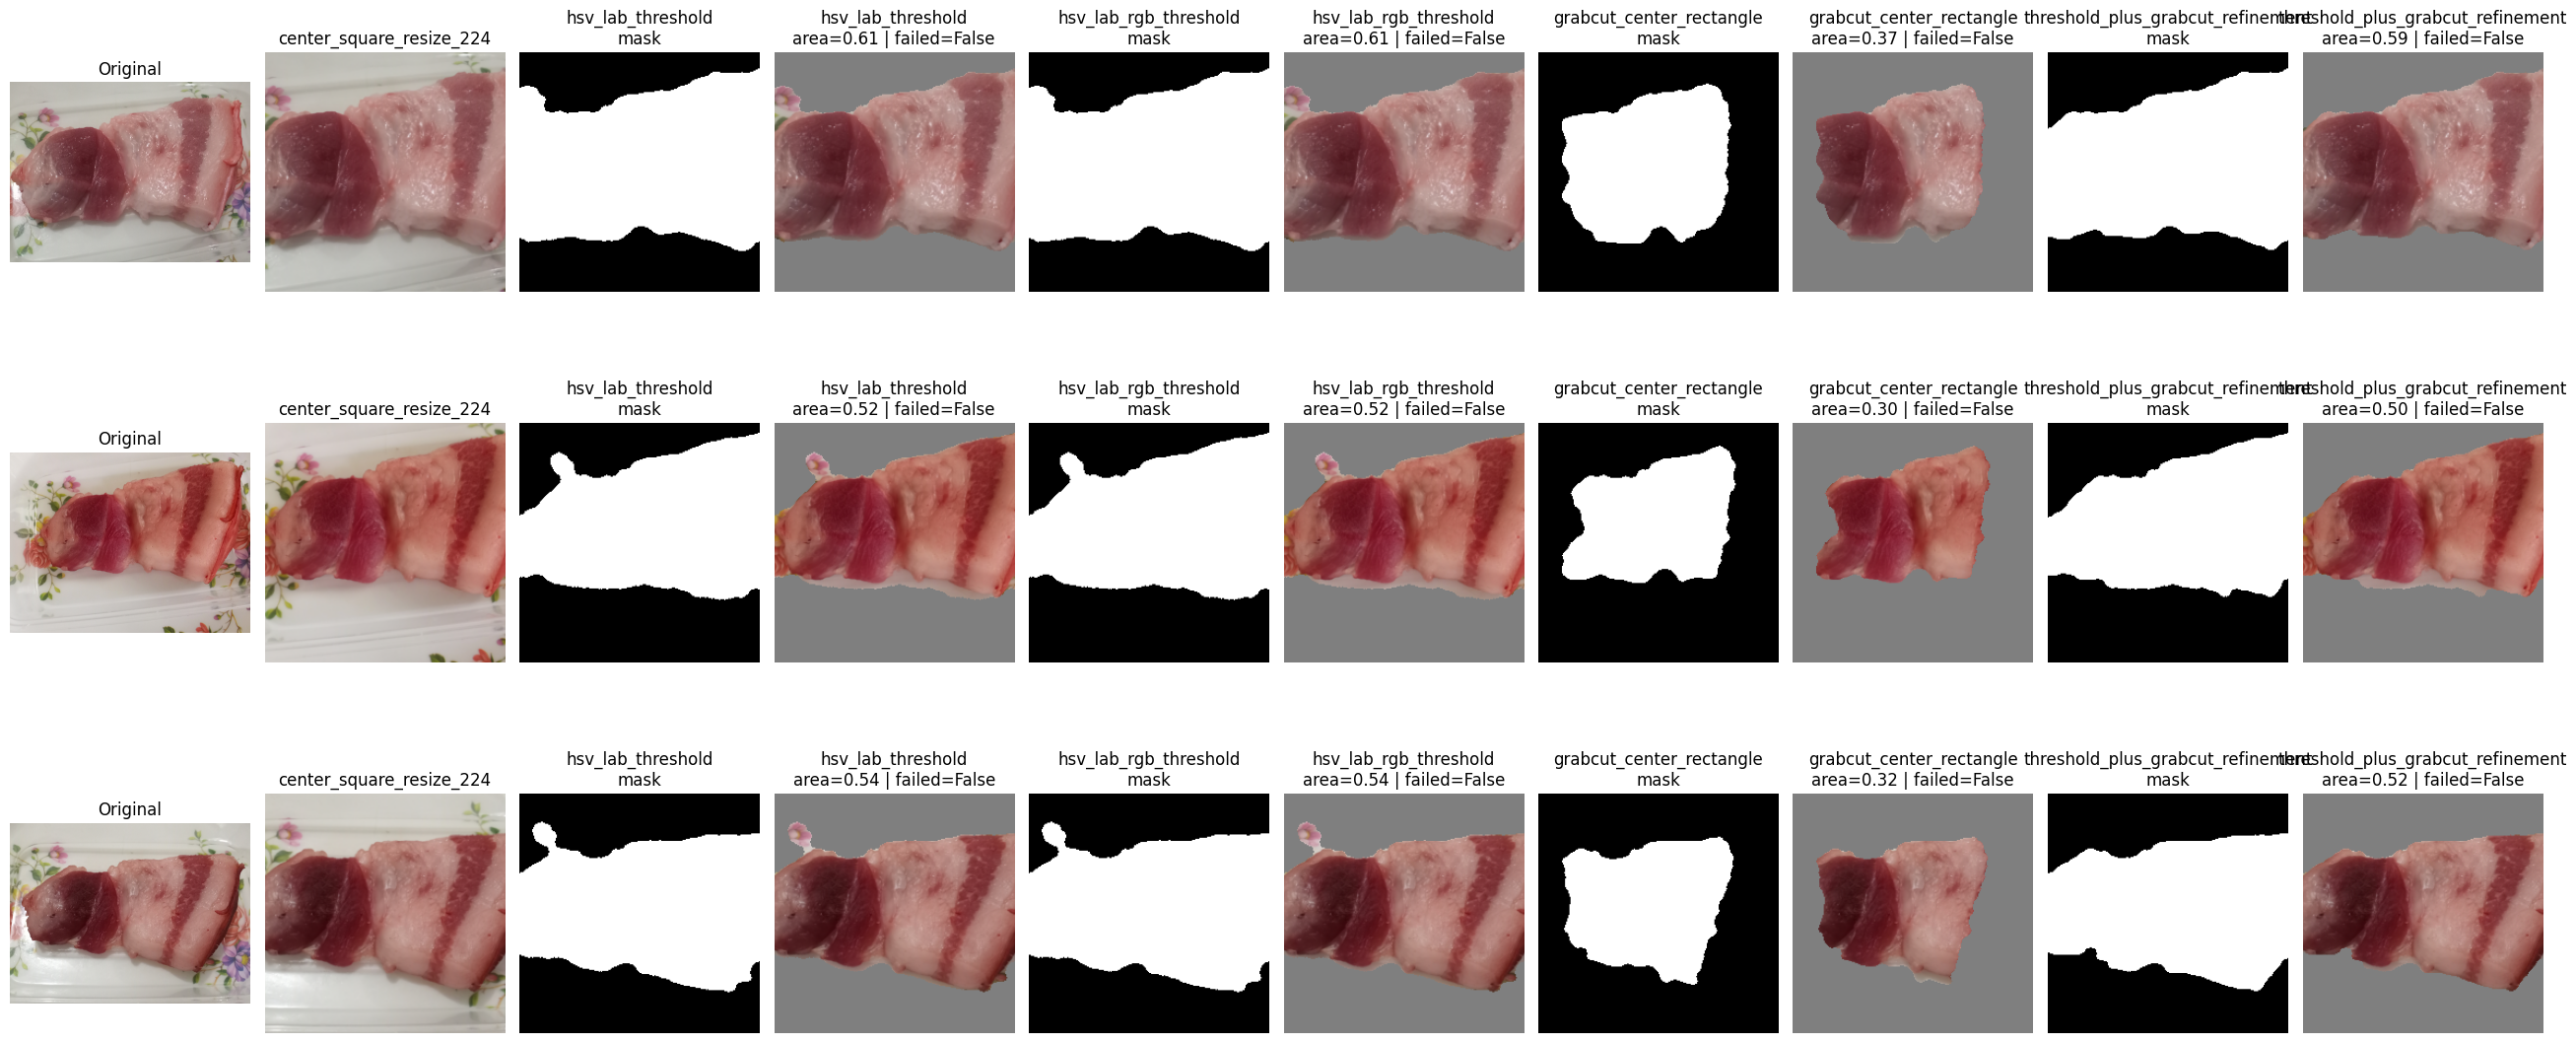

,image_path_resolved,sample_id,pork_cut,capture_source,label,method,mask_area_ratio,touches_border,number_of_components,center_overlap_ratio,segmentation_failed
0,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...,pork_belly_sample_3,belly,researcher_home,fresh,hsv_lab_threshold,0.611428,True,1,0.993782,False
1,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...,pork_belly_sample_3,belly,researcher_home,fresh,hsv_lab_rgb_threshold,0.611428,True,1,0.993782,False
2,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...,pork_belly_sample_3,belly,researcher_home,fresh,grabcut_center_rectangle,0.371811,False,1,0.987085,False
3,E:\Thesis Code\Pork Belly - Sample 3\Fresh - 0...,pork_belly_sample_3,belly,researcher_home,fresh,threshold_plus_grabcut_refinement,0.588090,True,1,0.993782,False
4,E:\Thesis Code\Pork Belly - Sample 3\Not Fresh...,pork_belly_sample_3,belly,researcher_home,not fresh,hsv_lab_threshold,0.523497,True,1,0.885842,False
5,E:\Thesis Code\Pork Belly - Sample 3\Not Fresh...,pork_belly_sample_3,belly,researcher_home,not fresh,hsv_lab_rgb_threshold,0.523497,True,1,0.885842,False
6,E:\Thesis Code\Pork Belly - Sample 3\Not Fresh...,pork_belly_sample_3,belly,researcher_home,not fresh,grabcut_center_rectangle,0.301479,False,1,0.795201,False
7,E:\Thesis Code\Pork Belly - Sample 3\Not Fresh...,pork_belly_sample_3,belly,researcher_home,not fresh,threshold_plus_grabcut_refinement,0.503767,True,1,0.885603,False
8,E:\Thesis Code\Pork Belly - Sample 3\Spoiled -...,pork_belly_sample_3,belly,researcher_home,spoiled,hsv_lab_threshold,0.536810,True,1,0.970424,False
9,E:\Thesis Code\Pork Belly - Sample 3\Spoiled -...,pork_belly_sample_3,belly,researcher_home,spoiled,hsv_lab_rgb_threshold,0.536810,True,1,0.970424,False


Saved preview grid: e:\Thesis Code\training_outputs\segmentation_experiment\figures\segmentation_method_comparison_grid_preview.png


In [6]:
# ============================================================
# One segmentation test on 3 images
# ============================================================
SEGMENTATION_TEST_ROWS = SELECTED_IMAGES_DF.head(3).copy().reset_index(drop=True)
display(SEGMENTATION_TEST_ROWS)

test_quality_rows = []
fig, axes = plt.subplots(len(SEGMENTATION_TEST_ROWS), 10, figsize=(26, 4 * len(SEGMENTATION_TEST_ROWS)))
if len(SEGMENTATION_TEST_ROWS) == 1:
    axes = np.array([axes])

method_to_col = {
    "hsv_lab_threshold": (2, 3),
    "hsv_lab_rgb_threshold": (4, 5),
    "grabcut_center_rectangle": (6, 7),
    "threshold_plus_grabcut_refinement": (8, 9),
}

for row_idx, row in SEGMENTATION_TEST_ROWS.iterrows():
    original_np, crop_np = load_center_square_resize_224(row["image_path_resolved"])
    axes[row_idx, 0].imshow(original_np)
    axes[row_idx, 0].set_title("Original")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(crop_np)
    axes[row_idx, 1].set_title("center_square_resize_224")
    axes[row_idx, 1].axis("off")

    for method_name in SEGMENTATION_METHODS:
        result = run_segmentation_method(method_name, crop_np)
        mask_col, preview_col = method_to_col[method_name]
        axes[row_idx, mask_col].imshow(result["mask"], cmap="gray")
        axes[row_idx, mask_col].set_title(method_name + "\nmask")
        axes[row_idx, mask_col].axis("off")

        axes[row_idx, preview_col].imshow(result["preview_gray"])
        axes[row_idx, preview_col].set_title(
            f"{method_name}\narea={result['quality']['mask_area_ratio']:.2f} | failed={result['segmentation_failed']}"
        )
        axes[row_idx, preview_col].axis("off")

        test_quality_rows.append(
            {
                "image_path_resolved": row["image_path_resolved"],
                "sample_id": row["sample_id"],
                "pork_cut": row["pork_cut"],
                "capture_source": row["capture_source"],
                "label": row["label"],
                "method": method_name,
                "mask_area_ratio": result["quality"]["mask_area_ratio"],
                "touches_border": result["quality"]["touches_border"],
                "number_of_components": result["quality"]["number_of_components"],
                "center_overlap_ratio": result["quality"]["center_overlap_ratio"],
                "segmentation_failed": result["segmentation_failed"],
            }
        )

plt.tight_layout()
preview_grid_path = FIGURES_ROOT / "segmentation_method_comparison_grid_preview.png"
plt.savefig(preview_grid_path, dpi=200, bbox_inches="tight")
plt.show()

SEGMENTATION_TEST_RESULTS_DF = pd.DataFrame(test_quality_rows)
display(SEGMENTATION_TEST_RESULTS_DF)
print(f"Saved preview grid: {preview_grid_path}")


In [7]:
# ============================================================
# Full experiment helpers
# ============================================================
def save_method_outputs(row, method_name, result, image_index):
    stem = f"{image_index:03d}_{row['sample_id']}_{row['label'].replace(' ', '_')}_{method_name}"
    mask_path = MASKS_ROOT / f"{stem}_mask.png"
    preview_black_path = PREVIEWS_ROOT / f"{stem}_black.png"
    preview_gray_path = PREVIEWS_ROOT / f"{stem}_gray.png"
    preview_mean_path = PREVIEWS_ROOT / f"{stem}_mean.png"

    Image.fromarray(result["mask"]).save(mask_path)
    Image.fromarray(result["preview_black"]).save(preview_black_path)
    Image.fromarray(result["preview_gray"]).save(preview_gray_path)
    Image.fromarray(result["preview_mean"]).save(preview_mean_path)
    return mask_path, preview_black_path, preview_gray_path, preview_mean_path


def create_individual_comparison_figure(row, original_np, crop_np, method_results, out_path):
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.reshape(2, 5)
    axes[0, 0].imshow(original_np)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")
    axes[0, 1].imshow(crop_np)
    axes[0, 1].set_title("center_square_resize_224")
    axes[0, 1].axis("off")
    axes[1, 0].axis("off")
    axes[1, 1].axis("off")

    for idx, method_name in enumerate(SEGMENTATION_METHODS):
        res = method_results[method_name]
        col = idx + 2 if idx < 3 else 4
        row_offset = 0 if idx < 3 else 1
        if idx < 3:
            axes[0, idx + 2].imshow(res["mask"], cmap="gray")
            axes[0, idx + 2].set_title(
                f"{method_name}\narea={res['quality']['mask_area_ratio']:.2f} | failed={res['segmentation_failed']}"
            )
            axes[0, idx + 2].axis("off")
            axes[1, idx + 2].imshow(res["preview_gray"])
            axes[1, idx + 2].set_title(f"{method_name}\npreferred preview")
            axes[1, idx + 2].axis("off")
        else:
            axes[0, 4].imshow(res["mask"], cmap="gray")
            axes[0, 4].set_title(
                f"{method_name}\narea={res['quality']['mask_area_ratio']:.2f} | failed={res['segmentation_failed']}"
            )
            axes[0, 4].axis("off")
            axes[1, 4].imshow(res["preview_gray"])
            axes[1, 4].set_title(f"{method_name}\npreferred preview")
            axes[1, 4].axis("off")

    fig.suptitle(
        f"{row['sample_id']} | {row['pork_cut']} | {row['capture_source']} | {row['label']}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


def run_segmentation_experiment():
    selected_df = select_representative_images().reset_index(drop=True)
    selected_df.to_csv(CSV_ROOT / "selected_segmentation_preview_images.csv", index=False)

    quality_rows = []
    grid_image_paths = []

    for image_index, row in selected_df.iterrows():
        original_np, crop_np = load_center_square_resize_224(row["image_path_resolved"])
        method_results = {}
        for method_name in SEGMENTATION_METHODS:
            result = run_segmentation_method(method_name, crop_np)
            method_results[method_name] = result
            mask_path, black_path, gray_path, mean_path = save_method_outputs(row, method_name, result, image_index)
            quality_rows.append(
                {
                    "image_path_resolved": row["image_path_resolved"],
                    "sample_id": row["sample_id"],
                    "pork_cut": row["pork_cut"],
                    "capture_source": row["capture_source"],
                    "label": row["label"],
                    "method": method_name,
                    "mask_area_ratio": result["quality"]["mask_area_ratio"],
                    "touches_border": result["quality"]["touches_border"],
                    "number_of_components": result["quality"]["number_of_components"],
                    "center_overlap_ratio": result["quality"]["center_overlap_ratio"],
                    "segmentation_failed": result["segmentation_failed"],
                    "mask_path": str(mask_path),
                    "preview_black_path": str(black_path),
                    "preview_gray_path": str(gray_path),
                    "preview_mean_path": str(mean_path),
                }
            )

        comparison_path = PREVIEWS_ROOT / f"{image_index:03d}_{row['sample_id']}_comparison.png"
        create_individual_comparison_figure(row, original_np, crop_np, method_results, comparison_path)
        grid_image_paths.append(comparison_path)

    quality_df = pd.DataFrame(quality_rows)
    quality_path = CSV_ROOT / "segmentation_quality_results.csv"
    quality_df.to_csv(quality_path, index=False)

    summary_df = (
        quality_df.groupby("method")
        .agg(
            number_of_images=("image_path_resolved", "count"),
            failed_count=("segmentation_failed", "sum"),
            mean_mask_area_ratio=("mask_area_ratio", "mean"),
            std_mask_area_ratio=("mask_area_ratio", "std"),
            mean_center_overlap_ratio=("center_overlap_ratio", "mean"),
        )
        .reset_index()
    )
    summary_df["failed_rate"] = summary_df["failed_count"] / summary_df["number_of_images"].clip(lower=1)
    summary_df["preferred_method_candidate"] = False
    if len(summary_df) > 0:
        summary_sorted = summary_df.sort_values(
            ["failed_rate", "mean_center_overlap_ratio", "mean_mask_area_ratio"],
            ascending=[True, False, False],
        ).reset_index(drop=True)
        best_method = summary_sorted.loc[0, "method"]
        summary_df.loc[summary_df["method"] == best_method, "preferred_method_candidate"] = True
    summary_path = CSV_ROOT / "segmentation_method_summary.csv"
    summary_df.to_csv(summary_path, index=False)

    if len(grid_image_paths) > 0:
        thumbs = [np.array(Image.open(path).convert("RGB")) for path in grid_image_paths]
        fig, axes = plt.subplots(len(thumbs), 1, figsize=(18, 6 * len(thumbs)))
        if len(thumbs) == 1:
            axes = np.array([axes])
        for idx, thumb in enumerate(thumbs):
            axes[idx].imshow(thumb)
            axes[idx].axis("off")
        plt.tight_layout()
        grid_path = FIGURES_ROOT / "segmentation_method_comparison_grid.png"
        plt.savefig(grid_path, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"Saved: {grid_path}")

    print(f"Saved: {quality_path}")
    print(f"Saved: {summary_path}")
    return {
        "selected_df": selected_df,
        "quality_df": quality_df,
        "summary_df": summary_df,
    }


## Segmentation Showcase

This section builds a fixed 12-image showcase:
- sample 1, 2, 3, 4
- one `fresh`, one `not fresh`, one `spoiled` image per sample
- test split preferred, then val, then train


In [8]:
SHOWCASE_SAMPLE_IDS = [
    "pork_shoulder_sample_1",
    "pork_shoulder_sample_2",
    "pork_belly_sample_3",
    "pork_belly_sample_4",
]

SHOWCASE_LABELS = ["fresh", "not fresh", "spoiled"]
PARTITION_PRIORITY = {"test": 0, "val": 1, "train": 2}


def build_segmentation_showcase_df():
    pool = pd.concat(CLEAN_SPLIT_DATA.values(), ignore_index=True).copy()
    pool["partition_priority"] = pool["dataset_partition"].map(PARTITION_PRIORITY).fillna(99).astype(int)

    selected_rows = []
    missing_pairs = []
    for sample_id in SHOWCASE_SAMPLE_IDS:
        for label_name in SHOWCASE_LABELS:
            subset = pool.loc[
                (pool["sample_id"] == sample_id)
                & (pool["label"] == label_name)
            ].copy()
            if len(subset) == 0:
                missing_pairs.append((sample_id, label_name))
                continue
            subset = subset.sort_values(
                ["partition_priority", "split_name", "image_file_name"],
                ascending=[True, True, True],
            ).reset_index(drop=True)
            selected_rows.append(subset.iloc[0].copy())

    if len(missing_pairs) > 0:
        print("[WARN] Missing showcase combinations:")
        for sample_id, label_name in missing_pairs:
            print(f"- {sample_id} | {label_name}")

    showcase_df = pd.DataFrame(selected_rows)
    showcase_df = showcase_df[
        [
            "image_path_resolved",
            "sample_id",
            "pork_cut",
            "capture_source",
            "label",
            "split_name",
            "dataset_partition",
        ]
    ].reset_index(drop=True)
    return showcase_df


def _sample_figure_path(sample_id):
    return FIGURES_ROOT / f"segmentation_showcase_{sample_id}.png"


def run_segmentation_showcase():
    showcase_df = build_segmentation_showcase_df()
    globals()["SEGMENTATION_SHOWCASE_DF"] = showcase_df

    selected_path = CSV_ROOT / "segmentation_showcase_selected_images.csv"
    showcase_df.to_csv(selected_path, index=False)
    display(showcase_df)
    print(f"Saved: {selected_path}")

    quality_rows = []

    def _render_showcase_figure(sample_df, out_path, figure_title):
        fig, axes = plt.subplots(len(sample_df), 10, figsize=(28, 4.2 * len(sample_df)))
        if len(sample_df) == 1:
            axes = np.array([axes])

        method_to_cols = {
            "hsv_lab_threshold": (2, 3),
            "hsv_lab_rgb_threshold": (4, 5),
            "grabcut_center_rectangle": (6, 7),
            "threshold_plus_grabcut_refinement": (8, 9),
        }

        for row_idx, (_, row) in enumerate(sample_df.iterrows()):
            original_np, crop_np = load_center_square_resize_224(row["image_path_resolved"])
            axes[row_idx, 0].imshow(original_np)
            axes[row_idx, 0].set_title(
                f"Original\n{row['sample_id']}\n{row['label']}",
                fontsize=9,
            )
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(crop_np)
            axes[row_idx, 1].set_title(
                "center_square_resize_224\n"
                f"{row['pork_cut']} | {row['capture_source']}\n"
                f"{row['split_name']} | {row['dataset_partition']}",
                fontsize=9,
            )
            axes[row_idx, 1].axis("off")

            for method_name in SEGMENTATION_METHODS:
                result = run_segmentation_method(method_name, crop_np)
                mask_col, preview_col = method_to_cols[method_name]

                axes[row_idx, mask_col].imshow(result["mask"], cmap="gray")
                axes[row_idx, mask_col].set_title(f"{method_name}\nmask", fontsize=8)
                axes[row_idx, mask_col].axis("off")

                axes[row_idx, preview_col].imshow(result["preview_gray"])
                axes[row_idx, preview_col].set_title(
                    f"{method_name}\n"
                    f"area={result['quality']['mask_area_ratio']:.2f} | "
                    f"center={result['quality']['center_overlap_ratio']:.2f}\n"
                    f"failed={result['segmentation_failed']}",
                    fontsize=8,
                )
                axes[row_idx, preview_col].axis("off")

                quality_rows.append(
                    {
                        "image_path_resolved": row["image_path_resolved"],
                        "sample_id": row["sample_id"],
                        "pork_cut": row["pork_cut"],
                        "capture_source": row["capture_source"],
                        "label": row["label"],
                        "split_name": row["split_name"],
                        "dataset_partition": row["dataset_partition"],
                        "method": method_name,
                        "mask_area_ratio": result["quality"]["mask_area_ratio"],
                        "touches_border": result["quality"]["touches_border"],
                        "number_of_components": result["quality"]["number_of_components"],
                        "center_overlap_ratio": result["quality"]["center_overlap_ratio"],
                        "segmentation_failed": result["segmentation_failed"],
                    }
                )

        fig.suptitle(figure_title, fontsize=14)
        plt.tight_layout()
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out_path}")

    for sample_id in SHOWCASE_SAMPLE_IDS:
        sample_df = showcase_df.loc[showcase_df["sample_id"] == sample_id].copy().reset_index(drop=True)
        if len(sample_df) == 0:
            continue
        _render_showcase_figure(
            sample_df=sample_df,
            out_path=_sample_figure_path(sample_id),
            figure_title=f"Segmentation Showcase | {sample_id}",
        )

    _render_showcase_figure(
        sample_df=showcase_df,
        out_path=FIGURES_ROOT / "segmentation_showcase_all_samples.png",
        figure_title="Segmentation Showcase | All Samples",
    )

    quality_df = pd.DataFrame(quality_rows)
    quality_path = CSV_ROOT / "segmentation_showcase_quality_results.csv"
    quality_df.to_csv(quality_path, index=False)
    display(quality_df)
    print(f"Saved: {quality_path}")

    return {
        "showcase_df": showcase_df,
        "quality_df": quality_df,
    }


## Decision Cell

Use this section after the full experiment runs.

Questions to answer:
1. Which segmentation method looks most stable?
2. Which method has the lowest failed rate?
3. Which method visually preserves pork best?
4. Should segmentation be used for model training now?
5. Or should segmentation remain future work?

Default recommendation:
- if masks are inconsistent, do **not** use segmentation for training yet
- keep segmentation as future work until failure modes are controlled


In [9]:
summary_path = CSV_ROOT / "segmentation_method_summary.csv"
if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    display(summary_df)
    if len(summary_df) > 0:
        stable_row = summary_df.sort_values(
            ["failed_rate", "mean_center_overlap_ratio", "mean_mask_area_ratio"],
            ascending=[True, False, False],
        ).iloc[0]
        print("Most stable method:", stable_row["method"])
        print("Lowest failed_rate:", stable_row["method"], "|", float(stable_row["failed_rate"]))
        if float(stable_row["failed_rate"]) > 0.15:
            print("Recommendation: segmentation should remain future work for now.")
        else:
            print("Recommendation: visually promising, but keep a conservative review before using it in training.")
else:
    print("Summary CSV not available yet. Run the full segmentation experiment first.")


,method,number_of_images,failed_count,mean_mask_area_ratio,std_mask_area_ratio,mean_center_overlap_ratio,failed_rate,preferred_method_candidate
0,grabcut_center_rectangle,12,1,0.371366,0.150140,0.831354,0.083333,False
1,hsv_lab_rgb_threshold,12,0,0.559946,0.144411,0.900743,0.000000,False
2,hsv_lab_threshold,12,0,0.569236,0.147570,0.911186,0.000000,True
3,threshold_plus_grabcut_refinement,12,0,0.516145,0.138998,0.895235,0.000000,False


Most stable method: hsv_lab_threshold
Lowest failed_rate: hsv_lab_threshold | 0.0
Recommendation: visually promising, but keep a conservative review before using it in training.


In [10]:
if RUN_SEGMENTATION_EXPERIMENT:
    run_segmentation_experiment()
else:
    print("Segmentation experiment functions are ready. Set RUN_SEGMENTATION_EXPERIMENT=True to run.")


Segmentation experiment functions are ready. Set RUN_SEGMENTATION_EXPERIMENT=True to run.
